In [1]:
# --------------------------------------------------
# Project Root
# --------------------------------------------------

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\IITG\Projects\audio_factor_disentanglement_v2


In [2]:
# --------------------------------------------------
# Imports
# --------------------------------------------------

import json
import pandas as pd
import numpy as np

from pathlib import Path
from tqdm import tqdm

from src.utils.config_loader import load_yaml
from src.utils.path_manager import PathManager
from src.utils.metadata_manager import MetadataManager

from src.preprocessing.fragment_dataset_builder import (
    FragmentDatasetBuilder
)

In [3]:
# --------------------------------------------------
# Load Config
# --------------------------------------------------

cfg = load_yaml(
    PROJECT_ROOT
    / "configs"
    / "data_config.yaml"
)

cfg

{'project_name': 'audio_factor_disentanglement_v2',
 'audio_extensions': ['.wav', '.ogg', '.m4a'],
 'dataset': {'raw_dir': 'data/raw',
  'processed_dir': 'data/processed',
  'metadata_dir': 'data/metadata',
  'fragment_dir': 'data/fragments',
  'feature_dir': 'data/features'},
 'outputs': {'figures_dir': 'outputs/figures',
  'checkpoint_dir': 'outputs/checkpoints',
  'swap_dir': 'outputs/swaps'},
 'audio': {'target_sr': 16000, 'mono': True, 'normalize_peak': True},
 'fragmentation': {'sample_rate': 16000,
  'vad_top_db': 25,
  'min_fragment_ms': 80,
  'max_fragment_ms': 600,
  'envelope_frame_length': 512,
  'envelope_hop_length': 128,
  'smoothing_window': 9,
  'min_valley_distance_ms': 80,
  'padding_percentile': 95}}

In [4]:
# --------------------------------------------------
# Setup Paths
# --------------------------------------------------

pm = PathManager(
    project_root=PROJECT_ROOT,
    config=cfg
)

PROCESSED_DIR = pm.get_path(
    cfg["dataset"]["processed_dir"]
)

FRAGMENT_DIR = pm.get_path(
    cfg["dataset"]["fragment_dir"]
)

METADATA_DIR = pm.get_path(
    cfg["dataset"]["metadata_dir"]
)

FRAGMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(PROCESSED_DIR)
print(FRAGMENT_DIR)
print(METADATA_DIR)

d:\IITG\Projects\audio_factor_disentanglement_v2\data\processed
d:\IITG\Projects\audio_factor_disentanglement_v2\data\fragments
d:\IITG\Projects\audio_factor_disentanglement_v2\data\metadata


In [5]:
# --------------------------------------------------
# Load Standardized Inventory
# --------------------------------------------------

inventory = MetadataManager.load_csv(
    METADATA_DIR
    / "audio_inventory_standardized.csv"
)

print(
    f"Files : {len(inventory)}"
)

inventory.head()

Files : 34


,original_path,processed_path,original_sr,processed_sr,original_channels,processed_channels,duration_sec,rms_before,rms_after,peak_before,peak_after,speaker,condition,split
0,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,48000,16000,2,1,2.090688,0.043961,0.141931,0.309737,1.0,s1,clean,train
1,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,48000,16000,2,1,2.133375,0.044886,0.148792,0.301668,1.0,s1,clean,train
2,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,48000,16000,2,1,1.920000,0.052495,0.162351,0.323342,1.0,s1,clean,train
3,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,48000,16000,2,1,1.962687,0.047763,0.170687,0.279826,1.0,s1,clean,train
4,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,48000,16000,2,1,2.133375,0.050399,0.155940,0.323192,1.0,s1,clean,train


In [6]:
# --------------------------------------------------
# Initialize Builder
# --------------------------------------------------

builder = FragmentDatasetBuilder(

    sr=
        cfg["fragmentation"]["sample_rate"],

    vad_top_db=
        cfg["fragmentation"]["vad_top_db"],

    min_ms=
        cfg["fragmentation"]["min_fragment_ms"],

    max_ms=
        cfg["fragmentation"]["max_fragment_ms"],

    padded_length=None
)

In [7]:
# --------------------------------------------------
# Estimate Padding Length
# --------------------------------------------------

import librosa

all_lengths = []

for _, row in inventory.iterrows():

    y, sr = librosa.load(
        row["processed_path"],
        sr=None
    )

    intervals = builder.vad.detect_regions(
        y
    )

    for start, end in intervals:

        fragments, _ = (
            builder.segmenter.segment_interval(
                y,
                start,
                end
            )
        )

        for s, e in fragments:

            all_lengths.append(
                e - s
            )

padding_length = int(

    np.percentile(

        all_lengths,

        cfg["fragmentation"][
            "padding_percentile"
        ]
    )
)

print(
    "Estimated Padding Length:",
    padding_length
)

print(
    "Number of Fragments:",
    len(all_lengths)
)

c:\Users\Dell\.conda\envs\betavae\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Estimated Padding Length: 6336
Number of Fragments: 311


In [8]:
# --------------------------------------------------
# Generate Fragments
# --------------------------------------------------

all_fragment_records = []

for _, row in tqdm(
    inventory.iterrows(),
    total=len(inventory)
):

    processed_file = Path(
        row["processed_path"]
    )

    utterance_name = (
        processed_file.stem
    )

    output_dir = (

        FRAGMENT_DIR

        / processed_file.parent.name

        / utterance_name
    )

    metadata = builder.process_file(

        audio_path=
            processed_file,

        output_dir=
            output_dir,

        speaker=
            row["speaker"],

        condition=
            row["condition"],

        split=
            row["split"],

        padded_length=
            padding_length
    )

    for fragment in metadata["fragments"]:

        all_fragment_records.append({

            "speaker":
                row["speaker"],

            "condition":
                row["condition"],

            "split":
                row["split"],

            "source_file":
                processed_file.name,

            **fragment
        })

100%|██████████| 34/34 [00:20<00:00,  1.67it/s]


In [9]:
# --------------------------------------------------
# Fragment Inventory
# --------------------------------------------------

fragment_inventory = pd.DataFrame(
    all_fragment_records
)

print(
    f"Fragments : {len(fragment_inventory)}"
)

fragment_inventory.head()

Fragments : 311


,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,end_time,duration,true_length,padded_length,padding_ratio,raw_file,tensor_file,total_fragments,relative_position
0,s1,clean,train,s1_clean_01.wav,0,0,0,10752,13056,0.672,0.816,0.144,2304,6336,0.636364,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.0
1,s1,clean,train,s1_clean_01.wav,1,1,0,13056,17408,0.816,1.088,0.272,4352,6336,0.313131,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.2
2,s1,clean,train,s1_clean_01.wav,2,2,1,18432,21888,1.152,1.368,0.216,3456,6336,0.454545,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.4
3,s1,clean,train,s1_clean_01.wav,3,3,1,21888,23552,1.368,1.472,0.104,1664,6336,0.737374,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.6
4,s1,clean,train,s1_clean_01.wav,4,4,1,23552,25088,1.472,1.568,0.096,1536,6336,0.757576,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.8


In [10]:
# --------------------------------------------------
# Save Fragment Inventory
# --------------------------------------------------

fragment_inventory_path = (

    METADATA_DIR
    / "fragment_inventory.csv"
)

MetadataManager.save_csv(

    fragment_inventory,

    fragment_inventory_path
)

print(
    fragment_inventory_path
)

d:\IITG\Projects\audio_factor_disentanglement_v2\data\metadata\fragment_inventory.csv


In [11]:
# --------------------------------------------------
# Basic Statistics
# --------------------------------------------------

display(

    fragment_inventory[
        [
            "duration",
            "true_length"
        ]
    ].describe()
)

,duration,true_length
count,311.000000,311.000000
mean,0.206208,3299.334405
std,0.091586,1465.371624
min,0.080000,1280.000000
25%,0.136000,2176.000000
50%,0.184000,2944.000000
75%,0.256000,4096.000000
max,0.528000,8448.000000


In [12]:
# --------------------------------------------------
# Fragment Count Per Audio
# --------------------------------------------------

display(

    fragment_inventory
    .groupby(
        "source_file"
    )
    .size()
    .sort_values(
        ascending=False
    )
    .head(20)
)

source_file
s2_noisy_05.wav      15
s2_noisy_02.wav      15
s2_noisy_01.wav      14
s1_noisy_04.wav      13
s2_clean_04.wav      13
s1_noisy_08.wav      12
s2_test_noisy.wav    12
s1_noisy_05.wav      11
s2_noisy_06.wav      11
s2_clean_08.wav      10
s1_noisy_06.wav      10
s2_noisy_04.wav      10
s2_clean_05.wav      10
s1_noisy_01.wav      10
s1_noisy_03.wav       9
s2_noisy_03.wav       9
s1_test_clean.wav     9
s1_noisy_02.wav       9
s2_noisy_08.wav       9
s2_clean_06.wav       8
dtype: int64

In [13]:
# --------------------------------------------------
# Fragment Count Per Speaker
# --------------------------------------------------

display(

    fragment_inventory
    .groupby(
        [
            "speaker",
            "condition"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
)

,speaker,condition,count
0,s1,clean,61
1,s1,noisy,80
2,s2,clean,68
3,s2,noisy,102


In [14]:
# --------------------------------------------------
# Visualization Imports
# --------------------------------------------------

import librosa
import librosa.display

import matplotlib.pyplot as plt

In [74]:
# --------------------------------------------------
# Select Sample
# --------------------------------------------------

sample_row = inventory.iloc[20]

sample_row

original_path         d:\IITG\Projects\audio_factor_disentanglement_...
processed_path        d:\IITG\Projects\audio_factor_disentanglement_...
original_sr                                                       48000
processed_sr                                                      16000
original_channels                                                     2
processed_channels                                                    1
duration_sec                                                      2.432
rms_before                                                      0.04011
rms_after                                                      0.212879
peak_before                                                    0.188418
peak_after                                                          1.0
speaker                                                              s2
condition                                                         clean
split                                                           

In [75]:
# --------------------------------------------------
# Load Audio
# --------------------------------------------------

y, sr = librosa.load(

    sample_row["processed_path"],

    sr=None
)

print(sr)
print(len(y))

16000
38912


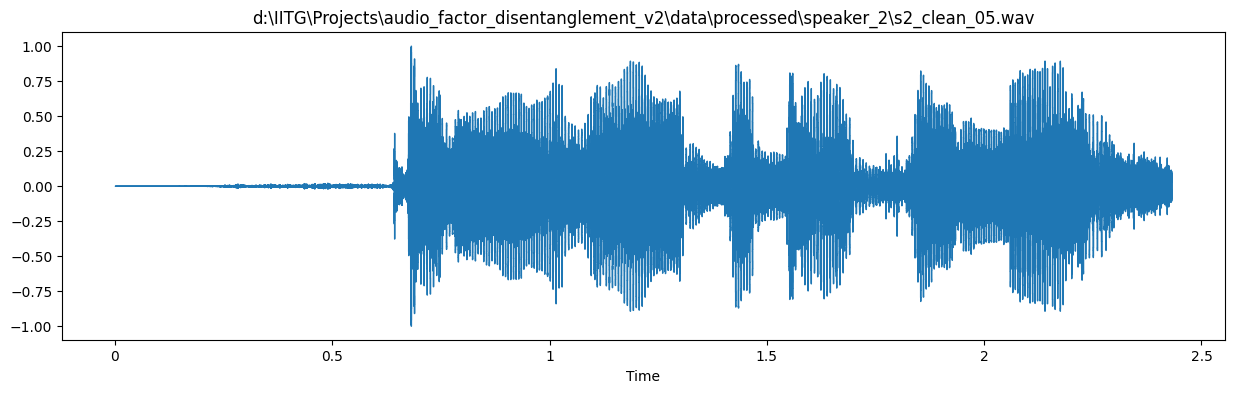

In [76]:
# --------------------------------------------------
# Plot Waveform
# --------------------------------------------------

plt.figure(
    figsize=(15,4)
)

librosa.display.waveshow(
    y,
    sr=sr
)

plt.title(
    sample_row["processed_path"]
)

plt.show()

In [77]:
# --------------------------------------------------
# VAD Regions
# --------------------------------------------------

intervals = builder.vad.detect_regions(
    y
)

intervals

array([[ 9728, 38912]])

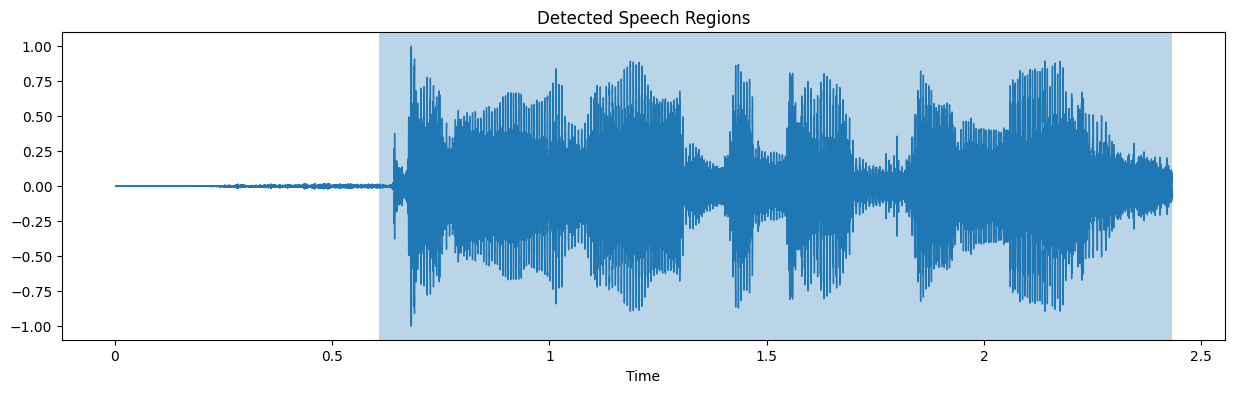

In [78]:
# --------------------------------------------------
# Plot VAD
# --------------------------------------------------

plt.figure(
    figsize=(15,4)
)

librosa.display.waveshow(
    y,
    sr=sr
)

for start, end in intervals:

    plt.axvspan(
        start/sr,
        end/sr,
        alpha=0.3
    )

plt.title(
    "Detected Speech Regions"
)

plt.show()

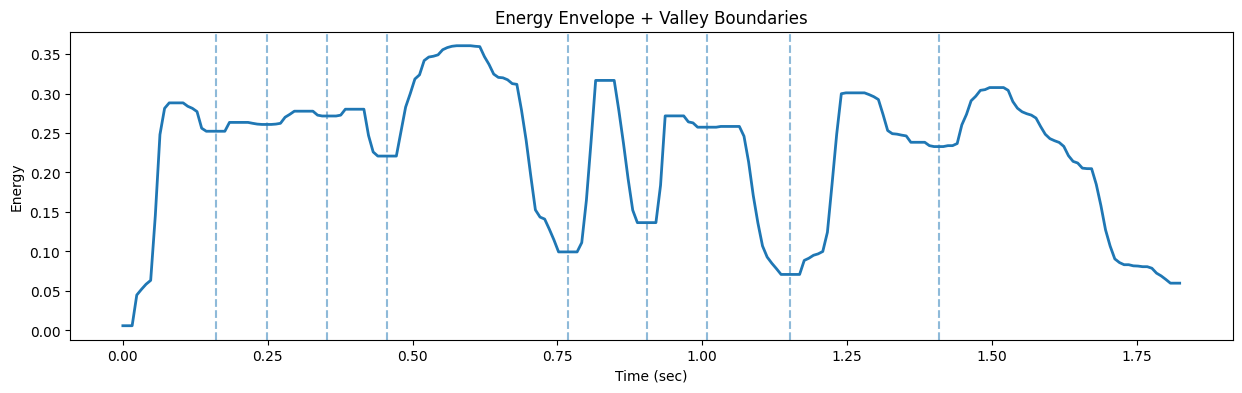

In [79]:
# --------------------------------------------------
# Envelope + Valley Detection
# --------------------------------------------------

speech = y[
    intervals[0][0]:
    intervals[0][1]
]

boundaries, envelope = (
    builder.segmenter.find_boundaries(
        speech
    )
)

times = (

    np.arange(
        len(envelope)
    )

    * builder.segmenter.hop_length

    / sr
)

plt.figure(
    figsize=(15,4)
)

plt.plot(
    times,
    envelope,
    linewidth=2
)

for b in boundaries:

    plt.axvline(
        b / sr,
        linestyle="--",
        alpha=0.5
    )

plt.title(
    "Energy Envelope + Valley Boundaries"
)

plt.xlabel(
    "Time (sec)"
)

plt.ylabel(
    "Energy"
)

plt.show()

In [80]:
# --------------------------------------------------
# Load Metadata JSON
# --------------------------------------------------

sample_folder = (

    FRAGMENT_DIR

    / Path(
        sample_row[
            "processed_path"
        ]
    ).parent.name

    / Path(
        sample_row[
            "processed_path"
        ]
    ).stem
)

with open(
    sample_folder
    / "metadata.json",
    "r"
) as f:

    metadata = json.load(f)

metadata.keys()

dict_keys(['speaker', 'condition', 'split', 'source_file', 'sample_rate', 'padded_length', 'num_vad_regions', 'fragments', 'total_fragments'])

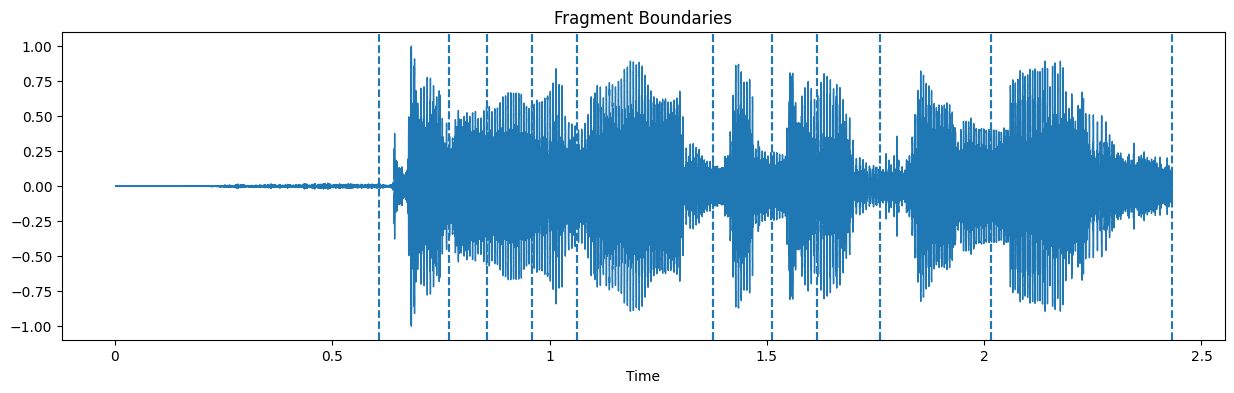

In [81]:
# --------------------------------------------------
# Plot Fragment Boundaries
# --------------------------------------------------

plt.figure(
    figsize=(15,4)
)

librosa.display.waveshow(
    y,
    sr=sr
)

for frag in metadata["fragments"]:

    plt.axvline(
        frag["start_time"],
        linestyle="--"
    )

    plt.axvline(
        frag["end_time"],
        linestyle="--"
    )

plt.title(
    "Fragment Boundaries"
)

plt.show()

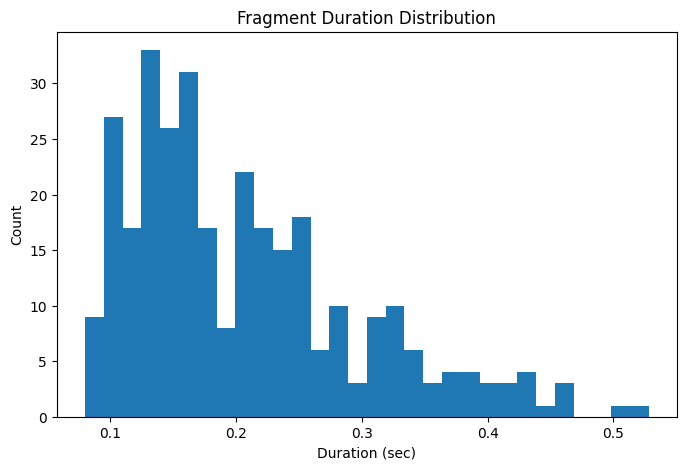

In [82]:
# --------------------------------------------------
# Fragment Duration Histogram
# --------------------------------------------------

plt.figure(
    figsize=(8,5)
)

plt.hist(
    fragment_inventory["duration"],
    bins=30
)

plt.title(
    "Fragment Duration Distribution"
)

plt.xlabel(
    "Duration (sec)"
)

plt.ylabel(
    "Count"
)

plt.show()

In [83]:
# --------------------------------------------------
# Longest Fragments
# --------------------------------------------------

fragment_inventory.sort_values(

    "duration",

    ascending=False

).head(20)

,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,end_time,duration,true_length,padded_length,padding_ratio,raw_file,tensor_file,total_fragments,relative_position
120,s1,noisy,train,s1_noisy_08.wav,0,0,0,2560,11008,0.160,0.688000,0.528000,8448,6336,-0.333333,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,12,0.000000
22,s1,clean,train,s1_clean_04.wav,3,3,0,11904,19968,0.744,1.248000,0.504000,8064,6336,-0.272727,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.600000
45,s1,clean,train,s1_clean_07.wav,5,5,0,20992,28288,1.312,1.768000,0.456000,7296,6336,-0.151515,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,1.000000
115,s1,noisy,train,s1_noisy_07.wav,1,1,0,5760,13056,0.360,0.816000,0.456000,7296,6336,-0.151515,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,6,0.200000
93,s1,noisy,train,s1_noisy_05.wav,0,0,0,2048,9344,0.128,0.584000,0.456000,7296,6336,-0.151515,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,11,0.000000
112,s1,noisy,train,s1_noisy_06.wav,8,8,0,26368,33536,1.648,2.096000,0.448000,7168,6336,-0.131313,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,10,0.888889
281,s2,noisy,train,s2_noisy_08.wav,0,0,0,2560,9472,0.160,0.592000,0.432000,6912,6336,-0.090909,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,9,0.000000
244,s2,noisy,train,s2_noisy_04.wav,6,6,0,25216,32128,1.576,2.008000,0.432000,6912,6336,-0.090909,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,10,0.666667
237,s2,noisy,train,s2_noisy_03.wav,8,8,0,28416,35328,1.776,2.208000,0.432000,6912,6336,-0.090909,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,9,1.000000
136,s2,clean,train,s2_clean_01.wav,4,4,0,22400,29184,1.400,1.824000,0.424000,6784,6336,-0.070707,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,5,1.000000


In [84]:
# --------------------------------------------------
# Shortest Fragments
# --------------------------------------------------

fragment_inventory.sort_values(

    "duration",

    ascending=True

).head(20)

,speaker,condition,split,source_file,fragment_id,position_index,vad_region_index,start_sample,end_sample,start_time,end_time,duration,true_length,padded_length,padding_ratio,raw_file,tensor_file,total_fragments,relative_position
231,s2,noisy,train,s2_noisy_03.wav,2,2,0,9600,10880,0.600,0.680,0.080,1280,6336,0.797980,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,9,0.250000
141,s2,clean,train,s2_clean_02.wav,4,4,0,22656,23936,1.416,1.496,0.080,1280,6336,0.797980,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,8,0.571429
157,s2,clean,train,s2_clean_04.wav,4,4,0,19968,21248,1.248,1.328,0.080,1280,6336,0.797980,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,13,0.333333
249,s2,noisy,train,s2_noisy_05.wav,1,1,0,8448,9856,0.528,0.616,0.088,1408,6336,0.777778,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,15,0.071429
86,s1,noisy,train,s1_noisy_04.wav,6,6,0,18560,19968,1.160,1.248,0.088,1408,6336,0.777778,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,13,0.500000
163,s2,clean,train,s2_clean_04.wav,10,10,0,33408,34816,2.088,2.176,0.088,1408,6336,0.777778,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,13,0.833333
240,s2,noisy,train,s2_noisy_04.wav,2,2,0,13184,14592,0.824,0.912,0.088,1408,6336,0.777778,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,10,0.222222
279,s2,noisy,train,s2_noisy_07.wav,5,5,0,17408,18816,1.088,1.176,0.088,1408,6336,0.777778,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,7,0.833333
167,s2,clean,train,s2_clean_05.wav,1,1,0,12288,13696,0.768,0.856,0.088,1408,6336,0.777778,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,10,0.111111
57,s1,noisy,train,s1_noisy_01.wav,5,5,0,19840,21376,1.240,1.336,0.096,1536,6336,0.757576,d:\IITG\Projects\audio_factor_disentanglement_...,d:\IITG\Projects\audio_factor_disentanglement_...,10,0.555556


In [85]:
# --------------------------------------------------
# Duration Quantiles
# --------------------------------------------------

fragment_inventory[
    "duration"
].quantile(
    [
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

0.25    0.136
0.50    0.184
0.75    0.256
0.90    0.336
0.95    0.396
0.99    0.456
Name: duration, dtype: float64

In [86]:
# --------------------------------------------------
# Padding Efficiency
# --------------------------------------------------

fragment_inventory[
    [
        "true_length",
        "padded_length"
    ]
].describe()

,true_length,padded_length
count,311.000000,311.0
mean,3299.334405,6336.0
std,1465.371624,0.0
min,1280.000000,6336.0
25%,2176.000000,6336.0
50%,2944.000000,6336.0
75%,4096.000000,6336.0
max,8448.000000,6336.0
